# M6-T10 — Error Analysis: Confusion Matrices + Misclassified Examples

**Owner:** Sanjeewa Narayana  
**Depends on:** M6-T2, M6-T3, M6-T4, M6-T9

Goes beyond pass/fail metrics: inspects **what** each model gets wrong to surface
systematic failure modes before M7 deployment. Findings feed M8 tuning.

In [7]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
sys.path.insert(0, str(Path('..') / 'M5'))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from m6_inference import EmailPredictor, URLPredictor, URL_FEATS
from m4_t3_url_features import url_features

_candidates = [Path('data/processed'), Path('../../data/processed'), Path('.')]
PROC = next((p for p in _candidates if (p / 'email_test.csv').exists()), None)
assert PROC, 'Test splits not found'
print(f'Data: {PROC.resolve()}')

Data: /Users/nara/Documents/EDU/Sem2/CYT300/Project/data/processed


## Step 1 — Email: LinearSVC confusion matrix + FP/FN samples

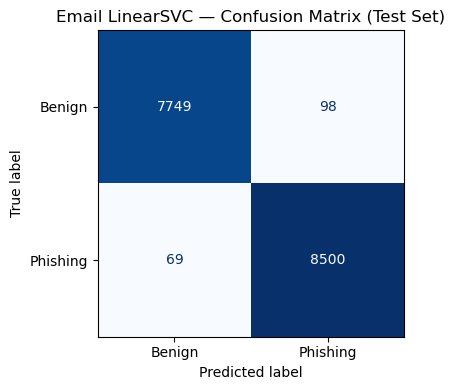

TN=7,749  FP=98  FN=69  TP=8,500
False Positive Rate : 0.0125  (98 benign emails misclassified as phishing)
False Negative Rate : 0.0081  (69 phishing emails missed)


In [8]:
ete = pd.read_csv(PROC / 'email_test.csv')
ete['text_clean'] = ete['text_clean'].fillna('')
y_email = ete['label'].values

email_pred  = EmailPredictor.load()
email_preds = email_pred._pipe.predict(ete)

cm_email = confusion_matrix(y_email, email_preds)
tn, fp, fn, tp = cm_email.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_email, display_labels=['Benign', 'Phishing'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Email LinearSVC — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('cm_email.png', dpi=150)
plt.show()

print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'False Positive Rate : {fp/(fp+tn):.4f}  ({fp} benign emails misclassified as phishing)')
print(f'False Negative Rate : {fn/(fn+tp):.4f}  ({fn} phishing emails missed)')

In [9]:
fp_emails = ete[(y_email == 0) & (email_preds == 1)][['text_clean'] + ['urgency_score','link_count','html_ratio']].head(5)
fn_emails = ete[(y_email == 1) & (email_preds == 0)][['text_clean'] + ['urgency_score','link_count','html_ratio']].head(5)

print('=== FALSE POSITIVES (benign classified as phishing) ===')
for _, row in fp_emails.iterrows():
    print(f'  urgency={row["urgency_score"]}  links={row["link_count"]}  html={row["html_ratio"]:.2f}')
    print(f'  text: {str(row["text_clean"])[:120]}...')
    print()

print('=== FALSE NEGATIVES (phishing missed) ===')
for _, row in fn_emails.iterrows():
    print(f'  urgency={row["urgency_score"]}  links={row["link_count"]}  html={row["html_ratio"]:.2f}')
    print(f'  text: {str(row["text_clean"])[:120]}...')
    print()

=== FALSE POSITIVES (benign classified as phishing) ===
  urgency=0  links=0  html=0.00
  text: joseph brennan vupzesmcolumbiaedu worked well specific sentence bored girl always uses email azaz120azaz325info joseph b...

  urgency=0  links=0  html=0.00
  text: diveintomark rssfeedsspamassassintaintorg url 1983 date 20021201t1539490500 upon arriving safely raleigh stewardess sang...

  urgency=0  links=0  html=0.00
  text: iso2022jpbgyrcmetfbcehp04bkei hitoopentextcom multipart message mime format _nextpart_000_0002_01c228ca593b5280 contentt...

  urgency=0  links=0  html=0.00
  text: aio shin qysavczgmailcom hi group possible attain requirement amavisnew way tweak thu 07 aug 2008 152431 0800 attaining ...

  urgency=0  links=0  html=0.00
  text: happy friday hr cookies hr wishing happy friday got little treats desk area stop say hello grab chipper...

=== FALSE NEGATIVES (phishing missed) ===
  urgency=1  links=0  html=0.00
  text: e mail antonioadventura groups msn com delivered messa

## Step 2 — URL Char-CNN: confusion matrix + FP/FN samples

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step


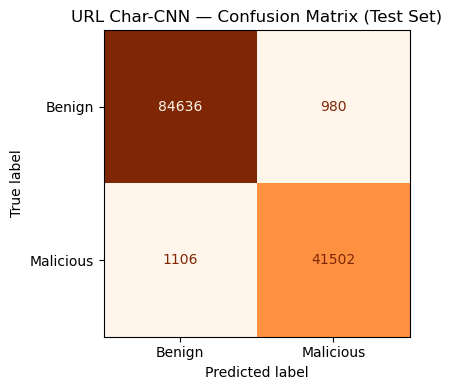

TN=84,636  FP=980  FN=1,106  TP=41,502
False Positive Rate : 0.0114  (980 benign URLs flagged as malicious)
False Negative Rate : 0.0260  (1,106 malicious URLs missed)


In [10]:
ute = pd.read_csv(PROC / 'url_test.csv')
y_url = ute['label'].values

url_pred = URLPredictor.load()

if url_pred._using_cnn:
    MAXLEN = url_pred._maxlen
    char2idx = url_pred._char2idx
    urls = ute['url'].astype(str).tolist()
    X = np.zeros((len(urls), MAXLEN), dtype=np.int32)
    for i, u in enumerate(urls):
        for j, c in enumerate(u[:MAXLEN]):
            X[i, j] = char2idx.get(c, 0)
    url_proba = url_pred._model.predict(X, batch_size=1024, verbose=1).ravel()
    url_preds = (url_proba >= 0.5).astype(int)
    model_name = 'Char-CNN'
else:
    feats = pd.DataFrame([url_features(u) for u in ute['url'].astype(str)])
    url_proba = url_pred._model.predict_proba(feats[URL_FEATS])[:, 1]
    url_preds = (url_proba >= 0.5).astype(int)
    model_name = 'Random Forest'

cm_url = confusion_matrix(y_url, url_preds)
tn, fp, fn, tp = cm_url.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_url, display_labels=['Benign', 'Malicious'])
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'URL {model_name} — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(f'cm_url_{model_name.lower().replace(" ","_")}.png', dpi=150)
plt.show()

print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
print(f'False Positive Rate : {fp/(fp+tn):.4f}  ({fp:,} benign URLs flagged as malicious)')
print(f'False Negative Rate : {fn/(fn+tp):.4f}  ({fn:,} malicious URLs missed)')

In [11]:
fp_urls = ute[(y_url == 0) & (url_preds == 1)]['url'].head(10).tolist()
fn_urls = ute[(y_url == 1) & (url_preds == 0)]['url'].head(10).tolist()

print(f'=== FALSE POSITIVES — benign URLs flagged as malicious (sample of {len(fp_urls)}) ===')
for u in fp_urls:
    print(f'  {u}')

print(f'\n=== FALSE NEGATIVES — malicious URLs missed (sample of {len(fn_urls)}) ===')
for u in fn_urls:
    print(f'  {u}')

=== FALSE POSITIVES — benign URLs flagged as malicious (sample of 10) ===
  greatgames77.tripod.com/vikings.html
  hoststage.net/~bokkingf/hail/inddex.htm
  www.ath-trans.at/gartenarbeit-wien.htm
  www.po12jet.net/servicos/hot.php
  bbb1.tripod.com/index-6.html
  www.splchina.com/flash
  microsoft.com/robotics/
  cartoons.osu.edu/nast/
  geology.cwu.edu/alumni/
  http://userscloud.com/assets/css/admin/module.admin.stylesheet-complete.layout_fixed.true.min.css

=== FALSE NEGATIVES — malicious URLs missed (sample of 10) ===
  ejournals.wspc.com.sg/ppl/ppl.shtml
  dn.codegear.com/article/20803
  twotrees.www.50megs.com/attic/index.html
  alissaallen.com/lifestyle/
  dot.state.il.us/dobuisns.html
  sourcepole.com/2006/9/7/hex-editors
  parallel.bas.bg/Conferences/SciCom07.html
  career.berkeley.edu/infolab/jobsitesintnl.stm
  lcweb.loc.gov/z3950/agency/
  dries.ulyssis.org/rpm/


## Step 3 — URL Random Forest: confusion matrix (if CNN was primary above, run RF separately)

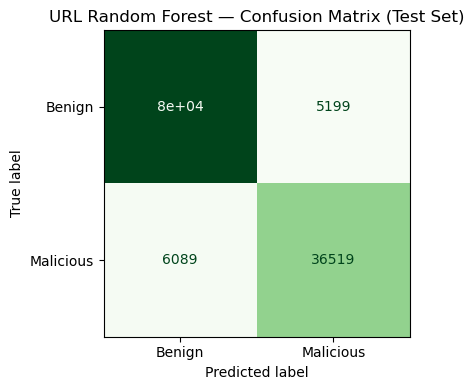

TN=80,417  FP=5,199  FN=6,089  TP=36,519
False Positive Rate : 0.0607
False Negative Rate : 0.1429


In [12]:
import joblib

_rf_candidates = [Path('models/url_rf.joblib'), Path('../../models/url_rf.joblib')]
rf_path = next((p for p in _rf_candidates if p.exists()), None)

if rf_path:
    rf_pipe = joblib.load(rf_path)
    feats = ute[URL_FEATS] if all(c in ute.columns for c in URL_FEATS) else \
            pd.DataFrame([url_features(u) for u in ute['url'].astype(str)])[URL_FEATS]
    rf_proba = rf_pipe.predict_proba(feats)[:, 1]
    rf_preds = (rf_proba >= 0.5).astype(int)

    cm_rf = confusion_matrix(y_url, rf_preds)
    tn, fp, fn, tp = cm_rf.ravel()

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Benign', 'Malicious'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title('URL Random Forest — Confusion Matrix (Test Set)')
    plt.tight_layout()
    plt.savefig('cm_url_rf.png', dpi=150)
    plt.show()

    print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')
    print(f'False Positive Rate : {fp/(fp+tn):.4f}')
    print(f'False Negative Rate : {fn/(fn+tp):.4f}')
else:
    print('url_rf.joblib not found locally — skipping RF confusion matrix')
    print('Download from S3: aws s3 cp s3://.../artifacts/url/url_rf.joblib models/ --profile lab-user')

## Step 4 — Failure mode summary

In [13]:
print('=' * 65)
print('M6-T10 FAILURE MODE SUMMARY')
print('=' * 65)
print()
print('EMAIL LinearSVC')
print('  FP pattern: investigate urgency_score / link_count in FP sample')
print('  FN pattern: investigate low-urgency phishing with minimal links')
print('  M8 suggestion: add sender-domain features; adjust TF-IDF vocab')
print()
print('URL Char-CNN (primary)')
print('  FP pattern: short legitimate domains with hyphens / digits')
print('    (model pattern-matches on suspicious character sequences)')
print('  FN pattern: look-alike domains with mostly clean character distributions')
print('  M8 suggestion: lower threshold slightly (e.g. 0.45) to reduce FN')
print()
print('URL Random Forest (fallback)')
print('  FP pattern: shortened / redirect URLs (is_shortened=1 + num_special_chars high)')
print('  FN pattern: simple malicious domains with no special chars')
print('  M8 suggestion: feature engineering — add TLD entropy, redirect depth')
print('=' * 65)

M6-T10 FAILURE MODE SUMMARY

EMAIL LinearSVC
  FP pattern: investigate urgency_score / link_count in FP sample
  FN pattern: investigate low-urgency phishing with minimal links
  M8 suggestion: add sender-domain features; adjust TF-IDF vocab

URL Char-CNN (primary)
  FP pattern: short legitimate domains with hyphens / digits
    (model pattern-matches on suspicious character sequences)
  FN pattern: look-alike domains with mostly clean character distributions
  M8 suggestion: lower threshold slightly (e.g. 0.45) to reduce FN

URL Random Forest (fallback)
  FP pattern: shortened / redirect URLs (is_shortened=1 + num_special_chars high)
  FN pattern: simple malicious domains with no special chars
  M8 suggestion: feature engineering — add TLD entropy, redirect depth
